In [2]:
import pandas as pd
import numpy as np

# Path to the dataset
DATA_PATH = "../data/UCI HAR Dataset/"

# Load feature names
features = pd.read_csv(DATA_PATH + "features.txt", sep=r"\s+", header=None, names=["idx", "feature"])
feature_names = features["feature"].tolist()

# Load activity labels (1-6 -> activity name)
activity_labels = pd.read_csv(DATA_PATH + "activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])
print(activity_labels)

   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


In [3]:
from collections import Counter

# Deduplicate feature names
counts = Counter()
unique_names = []
for name in feature_names:
    counts[name] += 1
    unique_names.append(f"{name}_{counts[name]}" if counts[name] > 1 else name)

# Load training data
X_train = pd.read_csv(DATA_PATH + "train/X_train.txt", sep=r"\s+", header=None, names=unique_names)
y_train = pd.read_csv(DATA_PATH + "train/y_train.txt", sep=r"\s+", header=None, names=["Activity"])
subject_train = pd.read_csv(DATA_PATH + "train/subject_train.txt", sep=r"\s+", header=None, names=["Subject"])

# Load test data
X_test = pd.read_csv(DATA_PATH + "test/X_test.txt", sep=r"\s+", header=None, names=unique_names)
y_test = pd.read_csv(DATA_PATH + "test/y_test.txt", sep=r"\s+", header=None, names=["Activity"])
subject_test = pd.read_csv(DATA_PATH + "test/subject_test.txt", sep=r"\s+", header=None, names=["Subject"])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
y_train shape: (7352, 1)


In [4]:
label_map = dict(zip(activity_labels["id"], activity_labels["activity"]))
y_train["ActivityName"] = y_train["Activity"].map(label_map)
y_test["ActivityName"] = y_test["Activity"].map(label_map)

y_train["ActivityName"].value_counts()

ActivityName
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [5]:
print("Missing values in X_train:", X_train.isnull().sum().sum())

Missing values in X_train: 0


## Step 3: Exploratory Data Analysis

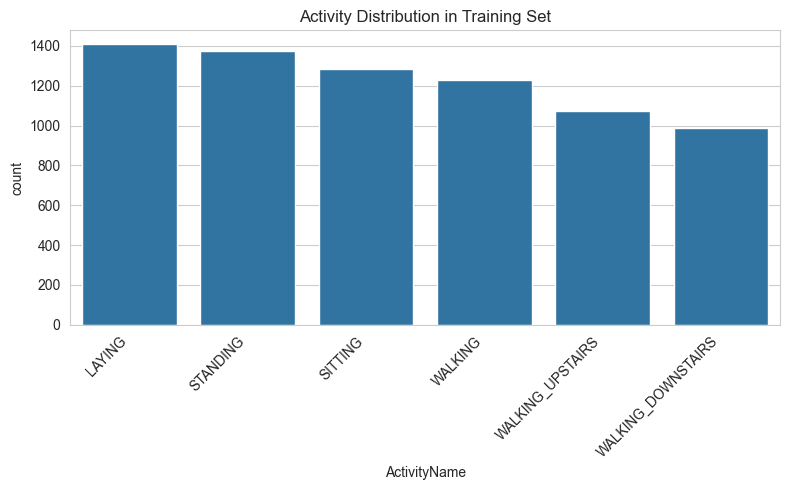

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(data=y_train, x="ActivityName", order=y_train["ActivityName"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Activity Distribution in Training Set")
plt.tight_layout()
plt.savefig("../outputs/activity_distribution.png", dpi=150)
plt.show()

In [7]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


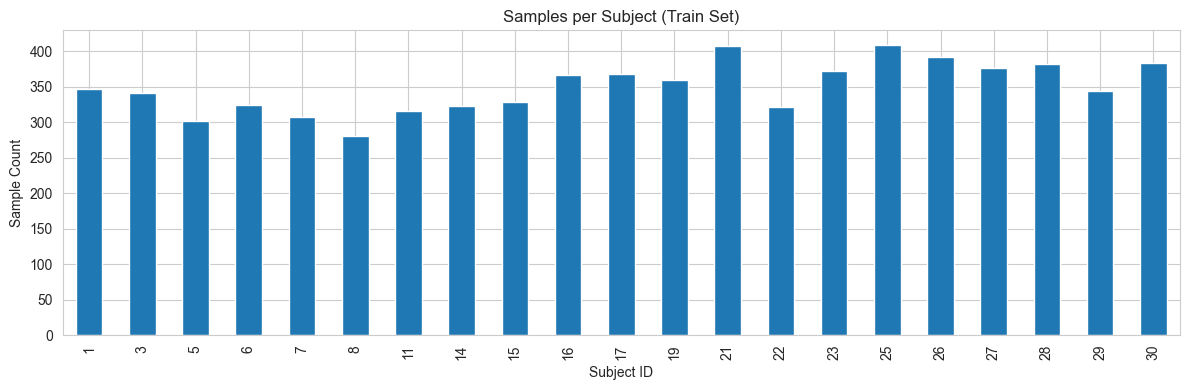

In [8]:
subject_train["Subject"].value_counts().sort_index().plot(kind="bar", figsize=(12,4))
plt.title("Samples per Subject (Train Set)")
plt.xlabel("Subject ID")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.savefig("../outputs/subject_distribution.png", dpi=150)
plt.show()

In [9]:
X_train.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
tBodyAcc-mean()-X,0.274488,0.070261,-1.000000,1.000000
tBodyAcc-mean()-Y,-0.017695,0.040811,-1.000000,1.000000
tBodyAcc-mean()-Z,-0.109141,0.056635,-1.000000,1.000000
tBodyAcc-std()-X,-0.605438,0.448734,-1.000000,1.000000
tBodyAcc-std()-Y,-0.510938,0.502645,-0.999873,0.916238
tBodyAcc-std()-Z,-0.604754,0.418687,-1.000000,1.000000
tBodyAcc-mad()-X,-0.630512,0.424073,-1.000000,1.000000
tBodyAcc-mad()-Y,-0.526907,0.485942,-1.000000,0.967664
tBodyAcc-mad()-Z,-0.606150,0.414122,-1.000000,1.000000
tBodyAcc-max()-X,-0.468604,0.544547,-1.000000,1.000000


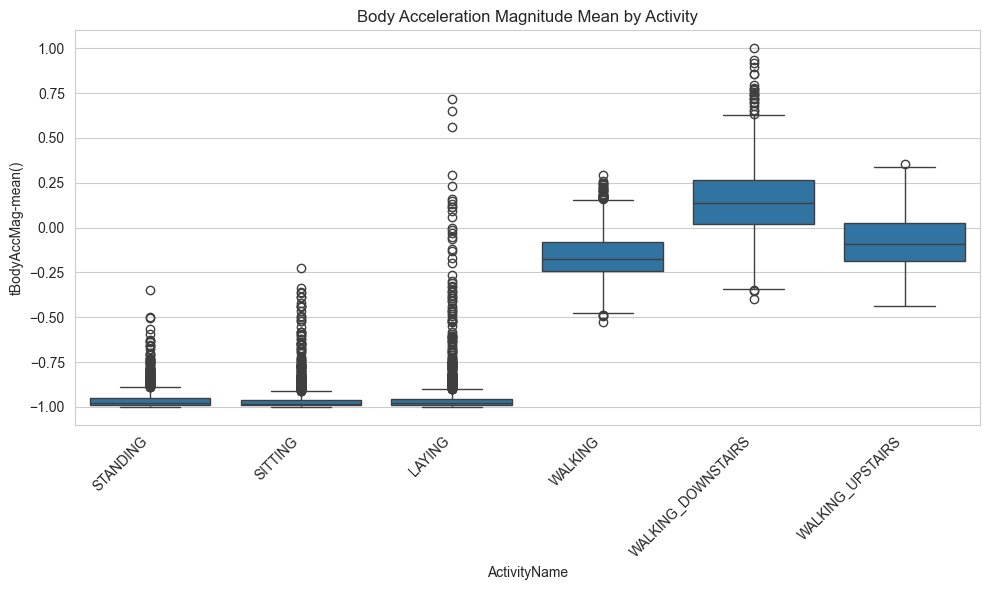

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(data=pd.concat([X_train["tBodyAccMag-mean()"], y_train["ActivityName"]], axis=1),
            x="ActivityName", y="tBodyAccMag-mean()")
plt.xticks(rotation=45, ha="right")
plt.title("Body Acceleration Magnitude Mean by Activity")
plt.tight_layout()
plt.savefig("../outputs/bodyaccmag_by_activity.png", dpi=150)
plt.show()

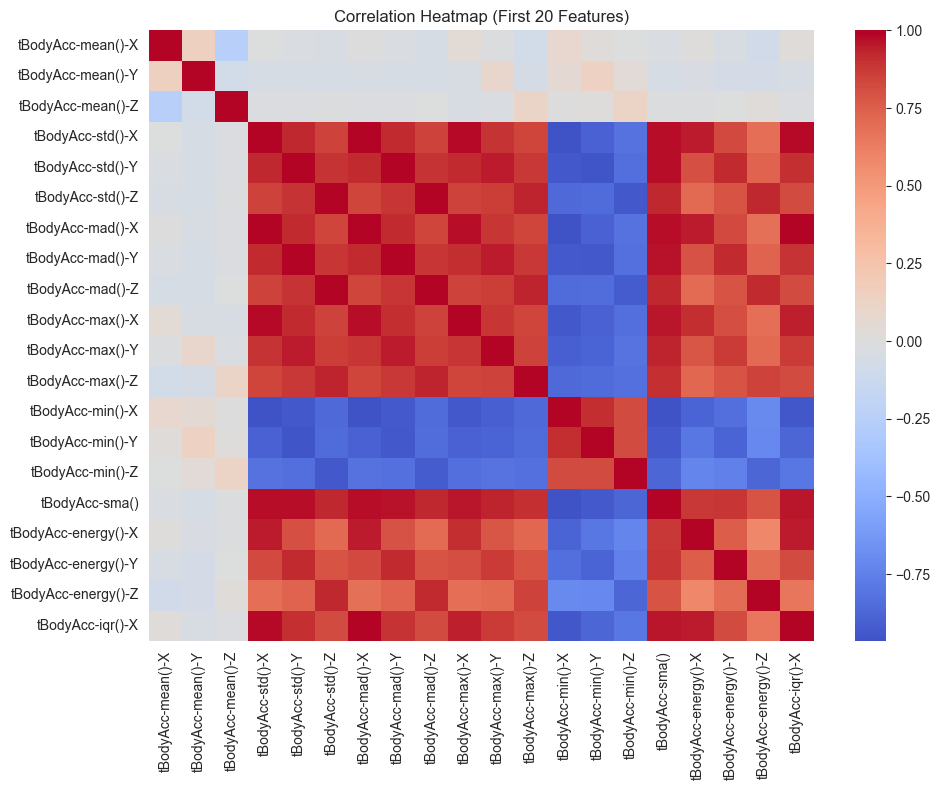

In [11]:
# Just a quick look at how correlated the first 20 features are
plt.figure(figsize=(10,8))
sns.heatmap(X_train.iloc[:, :20].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (First 20 Features)")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150)
plt.show()

#  Step 4: PCA — Dimensionality Reduction and Visualization

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit PCA with all components first, to inspect variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
import numpy as np
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print("Components needed for 90% variance:", np.argmax(cum_var >= 0.90) + 1)
print("Components needed for 95% variance:", np.argmax(cum_var >= 0.95) + 1)

Components needed for 90% variance: 63
Components needed for 95% variance: 102


/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


In [13]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [14]:
import sys
!{sys.executable} -m pip list | grep -iE "pandas|numpy|matplotlib|seaborn|scikit-learn"

matplotlib                3.9.4
matplotlib-inline         0.2.2
numpy                     2.0.2
pandas                    2.3.3
scikit-learn              1.6.1
seaborn                   0.13.2
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [15]:
import numpy as np
print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("Infs in X_train_scaled:", np.isinf(X_train_scaled).sum())

# Find which original columns have zero variance
zero_var_cols = X_train.columns[X_train.std() == 0]
print("Zero-variance columns:", list(zero_var_cols))

NaNs in X_train_scaled: 0
Infs in X_train_scaled: 0
Zero-variance columns: []


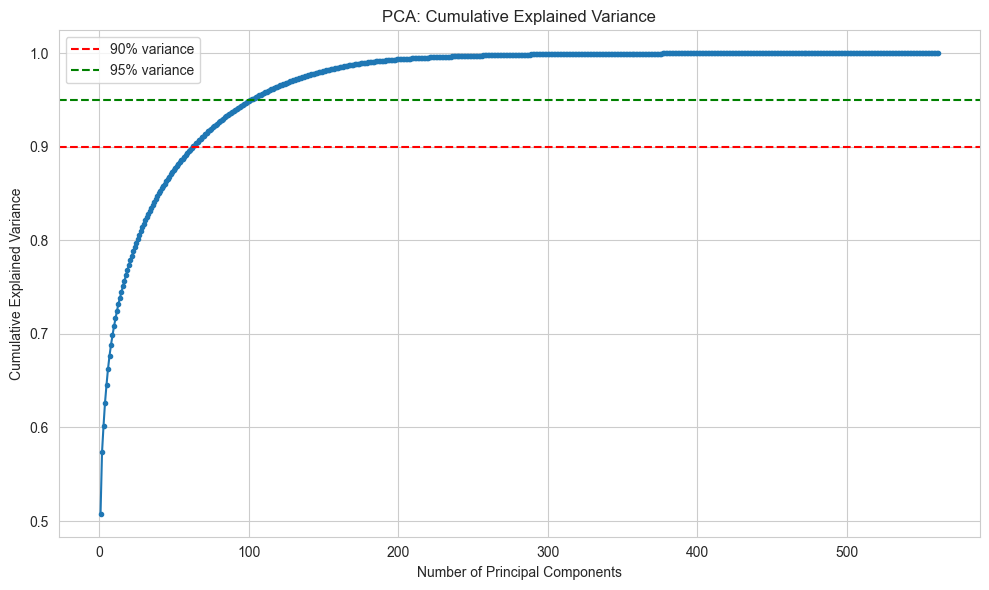

In [16]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='.')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/pca_explained_variance.png", dpi=150)
plt.show()

/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

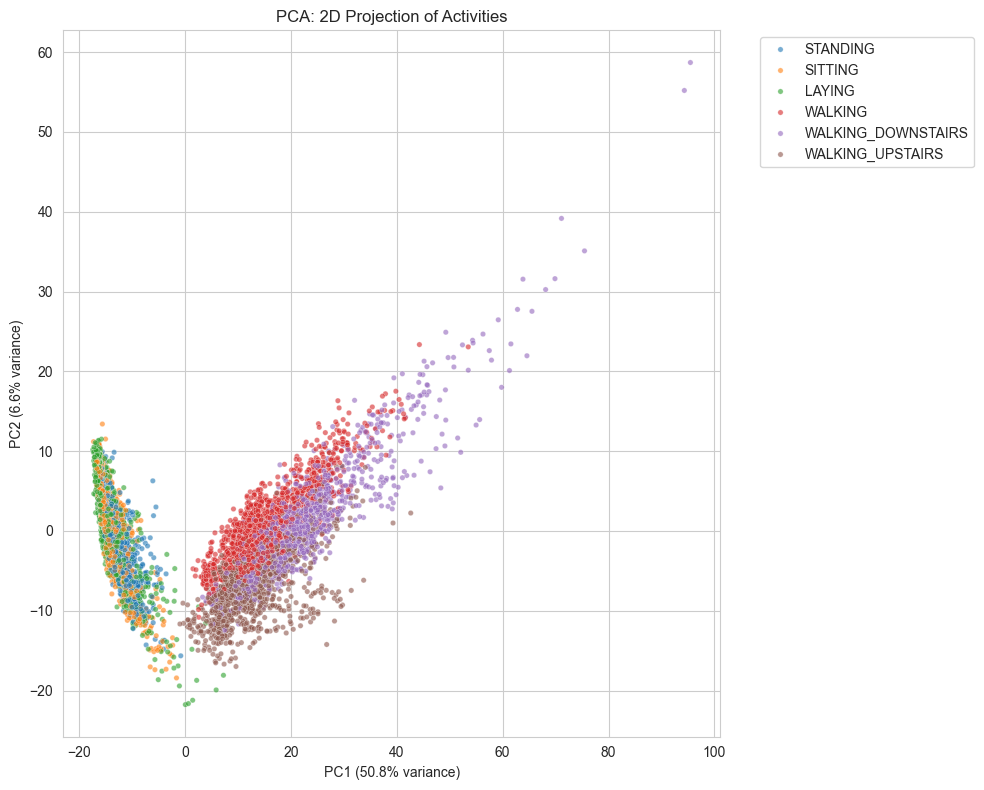

In [17]:
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10,8))
sns.scatterplot(x=X_train_pca2[:,0], y=X_train_pca2[:,1],
                 hue=y_train["ActivityName"], palette="tab10", alpha=0.6, s=15)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA: 2D Projection of Activities")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../outputs/pca_2d_scatter.png", dpi=150)
plt.show()

In [18]:
n_components_90 = np.argmax(cum_var >= 0.90) + 1
pca_final = PCA(n_components=n_components_90)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Reduced training shape:", X_train_pca.shape)

Reduced training shape: (7352, 63)


/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

# Step 5: Supervised Classification — KNN and Logistic Regression

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

start = time.time()
knn.fit(X_train_scaled, y_train["ActivityName"])
knn_pred = knn.predict(X_test_scaled)
knn_time = time.time() - start

knn_acc = accuracy_score(y_test["ActivityName"], knn_pred)
print(f"KNN (full features, euclidean) — Accuracy: {knn_acc:.4f} | Time: {knn_time:.2f}s")

KNN (full features, euclidean) — Accuracy: 0.8836 | Time: 0.19s


In [20]:
knn_pca = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

start = time.time()
knn_pca.fit(X_train_pca, y_train["ActivityName"])
knn_pca_pred = knn_pca.predict(X_test_pca)
knn_pca_time = time.time() - start

knn_pca_acc = accuracy_score(y_test["ActivityName"], knn_pca_pred)
print(f"KNN (PCA, 63 components, euclidean) — Accuracy: {knn_pca_acc:.4f} | Time: {knn_pca_time:.2f}s")

KNN (PCA, 63 components, euclidean) — Accuracy: 0.8622 | Time: 0.21s


In [21]:
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    knn_m = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn_m.fit(X_train_scaled, y_train["ActivityName"])
    pred_m = knn_m.predict(X_test_scaled)
    acc_m = accuracy_score(y_test["ActivityName"], pred_m)
    print(f"KNN ({metric}) — Accuracy: {acc_m:.4f}")

KNN (euclidean) — Accuracy: 0.8836
KNN (manhattan) — Accuracy: 0.9036
KNN (chebyshev) — Accuracy: 0.7044


In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, penalty='l2', C=1.0)

start = time.time()
logreg.fit(X_train_scaled, y_train["ActivityName"])
logreg_pred = logreg.predict(X_test_scaled)
logreg_time = time.time() - start

logreg_acc = accuracy_score(y_test["ActivityName"], logreg_pred)
print(f"Logistic Regression (full features) — Accuracy: {logreg_acc:.4f} | Time: {logreg_time:.2f}s")

/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: 

Logistic Regression (full features) — Accuracy: 0.9549 | Time: 0.29s


/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [23]:
logreg_pca = LogisticRegression(max_iter=1000, penalty='l2', C=1.0)
logreg_pca.fit(X_train_pca, y_train["ActivityName"])
logreg_pca_pred = logreg_pca.predict(X_test_pca)
logreg_pca_acc = accuracy_score(y_test["ActivityName"], logreg_pca_pred)
print(f"Logistic Regression (PCA) — Accuracy: {logreg_pca_acc:.4f}")

Logistic Regression (PCA) — Accuracy: 0.9216


/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: 

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.95      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



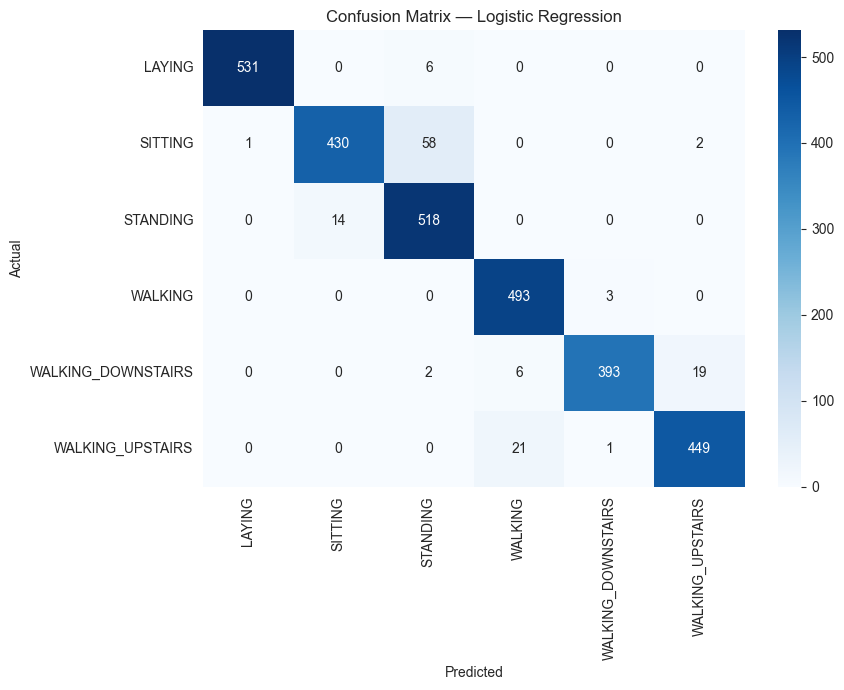

In [24]:
print(classification_report(y_test["ActivityName"], logreg_pred))

cm = confusion_matrix(y_test["ActivityName"], logreg_pred, labels=logreg.classes_)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg.classes_, yticklabels=logreg.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_logreg.png", dpi=150)
plt.show()

# Step 6: K-Means Clustering (Unsupervised Comparison)

/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

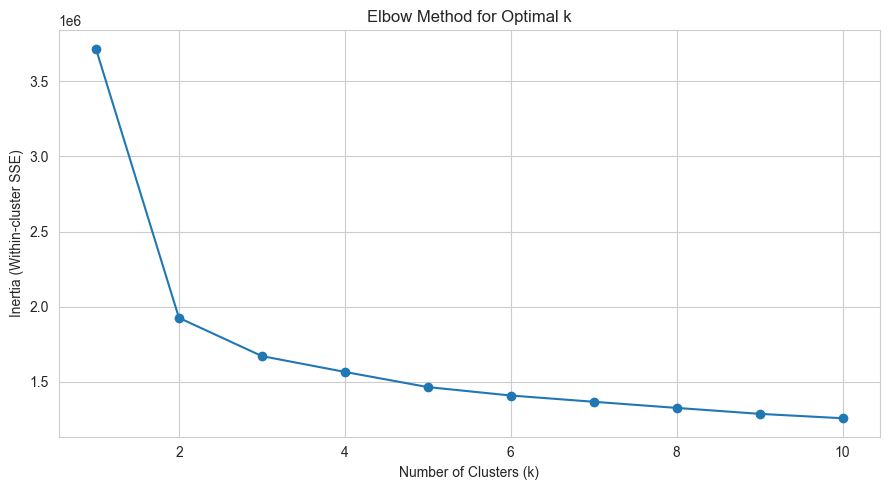

In [25]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(9,5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig("../outputs/kmeans_elbow.png", dpi=150)
plt.show()

In [26]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans6.fit_predict(X_train_pca)

ari = adjusted_rand_score(y_train["ActivityName"], cluster_labels)
nmi = normalized_mutual_info_score(y_train["ActivityName"], cluster_labels)
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

Adjusted Rand Index: 0.4203
Normalized Mutual Information: 0.5594


/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/june/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

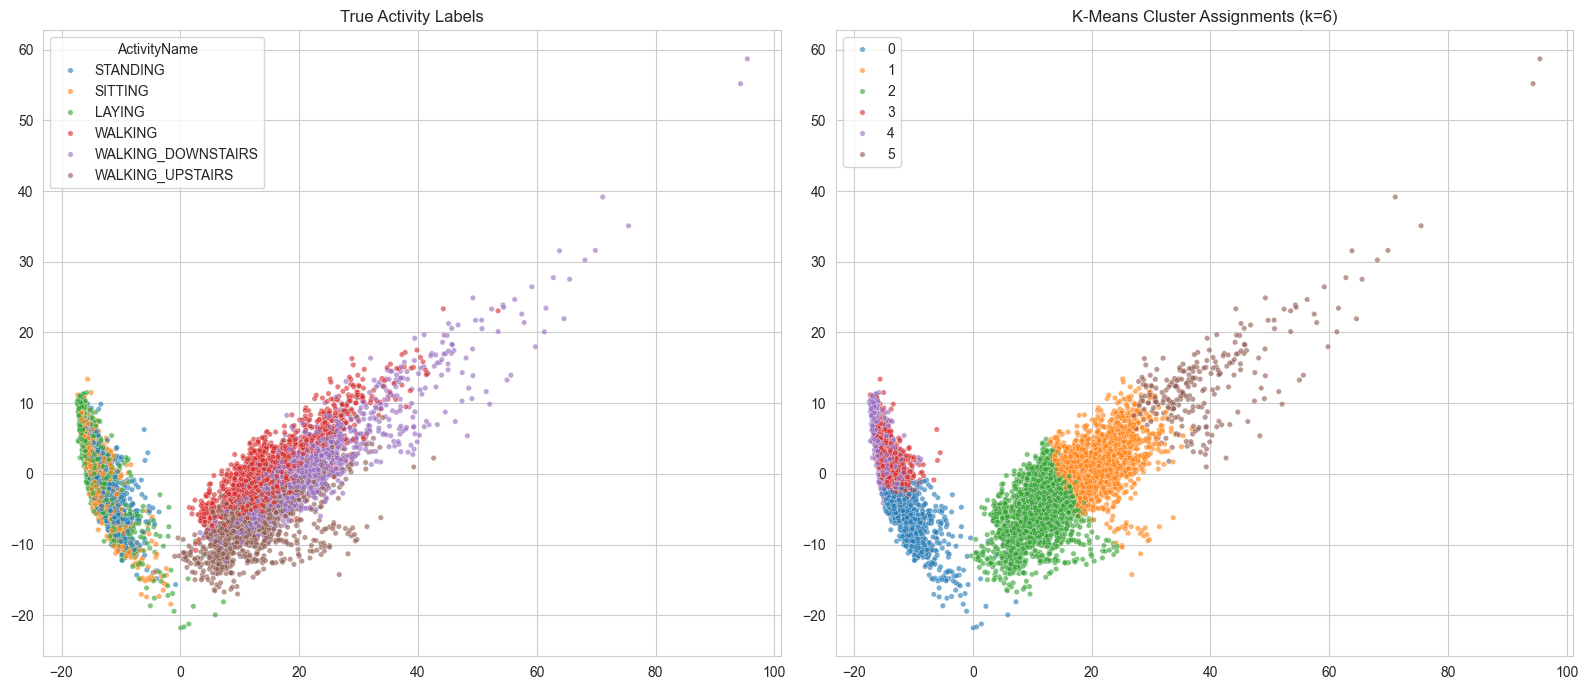

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

sns.scatterplot(x=X_train_pca2[:,0], y=X_train_pca2[:,1],
                 hue=y_train["ActivityName"], palette="tab10", alpha=0.6, s=15, ax=axes[0])
axes[0].set_title("True Activity Labels")

sns.scatterplot(x=X_train_pca2[:,0], y=X_train_pca2[:,1],
                 hue=cluster_labels, palette="tab10", alpha=0.6, s=15, ax=axes[1])
axes[1].set_title("K-Means Cluster Assignments (k=6)")

plt.tight_layout()
plt.savefig("../outputs/kmeans_vs_true_labels.png", dpi=150)
plt.show()

In [28]:
cluster_activity_df = pd.DataFrame({
    "Cluster": cluster_labels,
    "TrueActivity": y_train["ActivityName"].values
})
pd.crosstab(cluster_activity_df["Cluster"], cluster_activity_df["TrueActivity"])

TrueActivity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
Cluster,,,,,,
0,270,315,375,0,0,2
1,0,0,0,511,620,205
2,4,1,0,647,200,861
3,26,884,999,0,0,0
4,1107,86,0,0,0,0
5,0,0,0,68,166,5


In [31]:
summary = pd.DataFrame({
    "Model": ["KNN (Euclidean, Full)", "KNN (Euclidean, PCA)", "KNN (Manhattan, Full)",
              "KNN (Chebyshev, Full)", "Logistic Regression (Full)", "Logistic Regression (PCA)",
              "K-Means (k=6, unsupervised)"],
    "Accuracy": [0.8836, 0.8622, 0.9036, 0.7044, 0.9549, 0.9216, None],
    "Notes": ["Baseline", "Faster, slight accuracy drop", "Best KNN variant",
              "Worst — ignores most features", "Best overall model", "PCA trade-off",
              f"ARI={ari:.2f}, NMI={nmi:.2f} — no accuracy comparable to supervised"]
})
summary

,Model,Accuracy,Notes
0,"KNN (Euclidean, Full)",0.8836,Baseline
1,"KNN (Euclidean, PCA)",0.8622,"Faster, slight accuracy drop"
2,"KNN (Manhattan, Full)",0.9036,Best KNN variant
3,"KNN (Chebyshev, Full)",0.7044,Worst — ignores most features
4,Logistic Regression (Full),0.9549,Best overall model
5,Logistic Regression (PCA),0.9216,PCA trade-off
6,"K-Means (k=6, unsupervised)",NaN,"ARI=0.42, NMI=0.56 — no accuracy comparable to..."


In [32]:
import os
for f in sorted(os.listdir("../outputs")):
    print(f)

activity_distribution.png
bodyaccmag_by_activity.png
confusion_matrix_logreg.png
correlation_heatmap.png
kmeans_elbow.png
kmeans_vs_true_labels.png
pca_2d_scatter.png
pca_explained_variance.png
subject_distribution.png


In [33]:
import random

# Pick a few random test examples
sample_idx = random.sample(range(len(X_test)), 5)

for i in sample_idx:
    sample = X_test.iloc[[i]]
    true_label = y_test["ActivityName"].iloc[i]
    predicted = logreg.predict(scaler.transform(sample))[0]
    print(f"True: {true_label:20s} | Predicted: {predicted:20s} | {'✓' if true_label==predicted else '✗'}")

True: WALKING_DOWNSTAIRS   | Predicted: WALKING_DOWNSTAIRS   | ✓
True: STANDING             | Predicted: STANDING             | ✓
True: WALKING              | Predicted: WALKING              | ✓
True: WALKING_UPSTAIRS     | Predicted: WALKING_UPSTAIRS     | ✓
True: WALKING_UPSTAIRS     | Predicted: WALKING_UPSTAIRS     | ✓


In [34]:
# Show first 10 predictions vs the real answers
for i in range(10):
    true = y_test["ActivityName"].iloc[i]
    pred = knn_pred[i]
    match = "✓" if true == pred else "✗"
    print(f"{match}  True: {true:20s}  Predicted: {pred}")

✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✓  True: STANDING              Predicted: STANDING
✗  True: STANDING              Predicted: SITTING
